In [1]:
from pathlib import Path
import yaml
import os 
os.chdir(Path('/gpfs-calypso/home/globc/garcia/'))
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import glob
import numpy as np
import xarray as xr
import torch
from scipy import stats

from scenarIA.src.utils.metrics import NRMSE_g_ClimateBench, NRMSE_s_ClimateBench, NRMSE_ClimateBench
from scenarIA.src.data.dataloader import get_climatology
from scenarIA.src.utils.evalutils import EvaluationPlots, compare_temporal_profiles, compare_metrics_maps, compare_metrics
from scenarIA.src.utils.datautils import dataset_xr_formatting, weighted_global_mean
from scenarIA.src.utils.settings import PREDICTIONS_DIR, DATASET_DIR, GRAPHS_DIR, CONFIG_DIR, SIMUS_COLORS_DICT


/softs/Anaconda/2024.02-1/envs/gloenv_py3.11/lib/python3.12/site-packages/pyproj/__init__.py:91: UserWarning: Valid PROJ data directory not found. Either set the path using the environmental variable PROJ_DATA (PROJ 9.1+) | PROJ_LIB (PROJ<9.1) or with `pyproj.datadir.set_data_dir`.
  warnings.warn(str(err))


In [2]:
pred_path = PREDICTIONS_DIR / f'MPI-ESM1-2-LR/annual/exp9'

clim = xr.open_dataset(DATASET_DIR / f'MPI-ESM1-2-LR/annual/outputs_piControl.nc').mean('member')
clim = clim.sel(time=slice('1850-01-01', '2250-12-31')).mean('time')['pr'].values

true = xr.open_dataset( DATASET_DIR / f'MPI-ESM1-2-LR/annual/outputs_ssp245.nc').mean('member') # 50 members
lats = true.lat.values
t = true.time.values
y = true['pr'].values

# Open prediction files to compare
y_hat_dict = {'0': xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_ssp245_pr_attention-unet_seq5_mem30_epoch100_bs4_alpha0.nc')['pr'].values,
        '1': xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_ssp245_pr_attention-unet_seq5_mem30_epoch100_bs4_alpha1.nc')['pr'].values,
        '2': xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_ssp245_pr_attention-unet_seq5_mem30_epoch100_bs4_alpha2.nc')['pr'].values,
        '3': xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_ssp245_pr_attention-unet_seq5_mem30_epoch100_bs4_alpha3.nc')['pr'].values,
        '4': xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_ssp245_pr_attention-unet_seq5_mem30_epoch100_bs4_alpha4.nc')['pr'].values,
        '5': xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_ssp245_pr_attention-unet_seq5_mem30_epoch100_bs4_clim_64.nc')['pr'].values}
baseline = xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_ssp245_pr_pattern-scaling_seq1_mem30.nc')['pr'].values
y = y - clim
baseline = baseline - clim
for test, y_hat in y_hat_dict.items():
    y_hat_dict[test] = y_hat - clim

torch.Size([21, 96, 192])
{'NRMSEg': tensor(0.1261), 'NRMSEs': tensor(1.0605), 'NRMSE': tensor(1.6910)}
(6, 10)
(6, 10)
(6, 10)


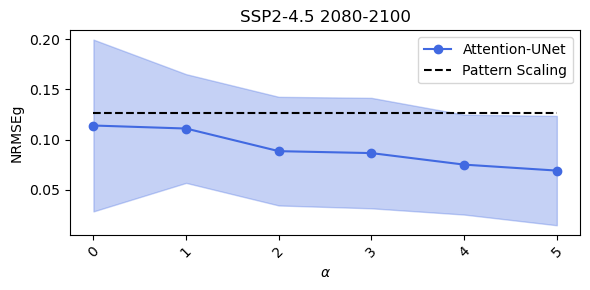

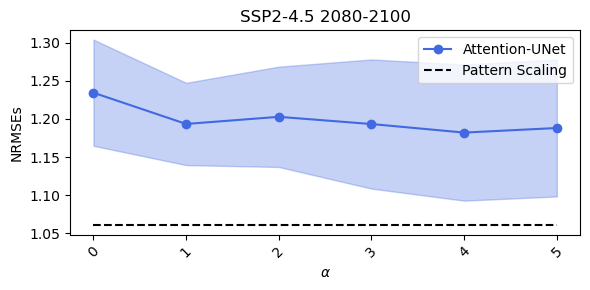

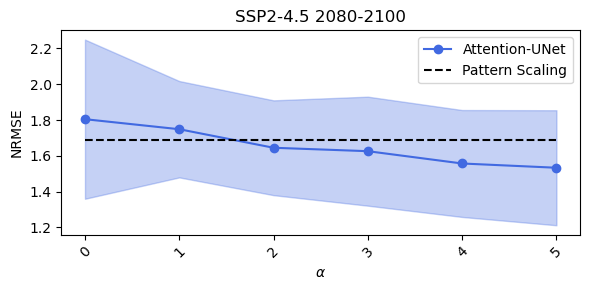

In [9]:
y = torch.Tensor(y)
lats = torch.Tensor(lats)

# Séparer le baseline (un seul run, shape [time, lat, lon]) des autres tests
y_hat_dict = dict(y_hat_dict)  # copie pour ne pas modifier l'original
y_baseline = torch.Tensor(baseline)[0]

y = y[-21:,:,:]
y_baseline = y_baseline[-21:,:,:]

print(y_baseline.shape)
baseline_scores = {
    'NRMSEg': NRMSE_g_ClimateBench(y_baseline, y, lats, normalize=True, weights_normalization='sum'),
    'NRMSEs': NRMSE_s_ClimateBench(y_baseline, y, lats, normalize=True, weights_normalization='sum'),
    'NRMSE':  NRMSE_ClimateBench(y_baseline, y, lats),
}
print(baseline_scores)

# Scores des modèles à plusieurs runs (shape [seed, time, lat, lon])
scores_dict = {'NRMSEg': [], 'NRMSEs': [], 'NRMSE': []}
model_names = list(y_hat_dict.keys())

for y_hat in y_hat_dict.values():
    y_hat = torch.Tensor(y_hat)[:,-21:,:,:]
    scores_dict['NRMSEg'].append(np.stack([NRMSE_g_ClimateBench(r, y, lats, normalize=True, weights_normalization='sum') for r in y_hat]))
    scores_dict['NRMSEs'].append(np.stack([NRMSE_s_ClimateBench(r, y, lats, normalize=True, weights_normalization='sum') for r in y_hat]))
    scores_dict['NRMSE'].append(np.stack([NRMSE_ClimateBench(r, y, lats) for r in y_hat]))

# Une figure par métrique
x = np.arange(len(model_names))
for metric_name, metric_list in scores_dict.items():
    metric = np.stack(metric_list)  # shape: [n_models, n_seeds]

    plt.figure(figsize=(6, 3))
    print(metric.shape)
    #for seed in range(metric.shape[1]):
        #plt.plot(x, metric[:, seed], marker='^', label=f'seed {seed}')
    plt.plot(x, metric.mean(axis=1), marker='o', label=f'Attention-UNet', color='royalblue')
    plt.fill_between(x, metric.mean(axis=1)-1*metric.std(axis=1), metric.mean(axis=1)+1*metric.std(axis=1), alpha=0.3, color='royalblue')
    plt.hlines(baseline_scores[metric_name], x.min(), x.max(), label='Pattern Scaling', linestyle='--', color='k')

    plt.xticks(x, model_names, rotation=45)
    plt.ylabel(metric_name)
    plt.xlabel(r'$\alpha$')
    plt.title('SSP2-4.5 2080-2100') 
    plt.legend()
    plt.tight_layout()

plt.show()